# 🎯 Ziel dieser Lektion: Multi-Layer Perceptron (MLP)

**Was wollen wir erreichen?** 
Wir erweitern unser einfaches Modell zu einem "Multi-Layer Perceptron". Das bedeutet, wir fügen versteckte Schichten (Hidden Layers) hinzu, um komplexe, nicht-lineare Probleme zu lösen.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Komplexe Daten (wie das XOR-Problem), die man nicht mit einer einfachen geraden Linie trennen kann.
- **Endziel (Gesucht):** Ein tiefes neuronales Netz, das komplizierte Muster erkennt und eine gebogene Entscheidungsgrenze zieht.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Komplexe Daten laden` ➔ `Versteckte Schichten (Hidden Layers) bauen` ➔ `Nicht-lineare Aktivierungen nutzen` ➔ `Modell trainieren` ➔ `Komplexe Entscheidungsgrenze visualisieren`


## Tag 03 - MLP - Anfaenger

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_moons` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_moons(n_samples=1000, noise=0.2, ra...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(16, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `modell.compile(optimizer='adam', loss='binary_c...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `print(f"\nTestgenauigkeit: {modell.evaluate(X_t...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


Model: "MLP_Halbmonde"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 schicht_1 (Dense)           (None, 16)                48        


 schicht_2 (Dense)           (None, 8)                 136       


...

Total params: 193


Trainable params: 193


Non-trainable params: 0


_________________________________________________________________



Testgenauigkeit: 96.50%


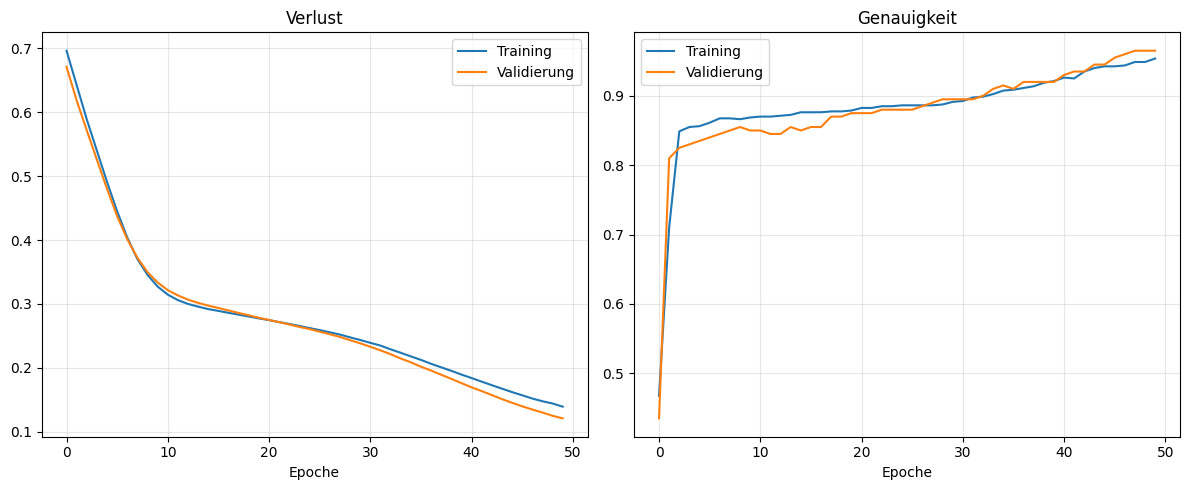

In [1]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Anfänger
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Build and train your first MLP with Keras
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

# Halbmonde Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# MLP erstellen
modell = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,), name='schicht_1'),
    tf.keras.layers.Dense(8, activation='relu', name='schicht_2'),
    tf.keras.layers.Dense(1, activation='sigmoid', name='ausgabe'),
], name='MLP_Halbmonde')

modell.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modell.summary()

# Training
history = modell.fit(X_train, y_train, validation_data=(X_test, y_test),
                     epochs=50, batch_size=32, verbose=0)

print(f"\nTestgenauigkeit: {modell.evaluate(X_test, y_test, verbose=0)[1]:.2%}")

# Lernkurven visualisieren
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validierung')
axes[0].set_title('Verlust'); axes[0].set_xlabel('Epoche'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validierung')
axes[1].set_title('Genauigkeit'); axes[1].set_xlabel('Epoche'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_circles` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_circles(n_samples=500, noise=0.1, f...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(32, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `modell.compile(optimizer='adam', loss='binary_c...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `xx, yy = np.meshgrid(np.linspace(x_min, x_max, ...` | Erstellt ein 2D-Raster aus Punkten. Wird oft verwendet, um 3D-Graphen oder Konturdiagramme zu zeichnen. |
| `Z = modell.predict(np.c_[xx.ravel(), yy.ravel()...` | Ändert die Dimensionen oder Form der Daten, ohne die Daten selbst zu verändern (z.B. aus einer Liste eine 2x2 Matrix machen). |
| `ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', ...` | Zeichnet ein farbig ausgefülltes Konturdiagramm (wie auf einer topografischen Landkarte, oft für Entscheidungsgrenzen). |
| `farben = ['red' if yi == 0 else 'blue' for yi i...` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


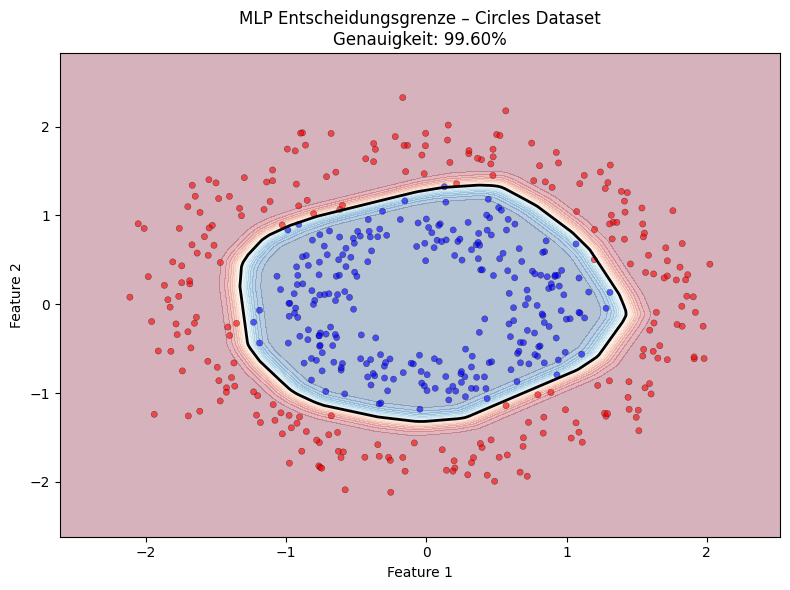

In [2]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Anfänger
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize MLP decision boundary on 2D data
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

# Konzentrische Kreise – nicht linear trennbar
X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# MLP aufbauen und trainieren
modell = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
modell.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modell.fit(X_std, y, epochs=100, verbose=0)

# Entscheidungsgrenze berechnen
x_min, x_max = X_std[:,0].min()-0.5, X_std[:,0].max()+0.5
y_min, y_max = X_std[:,1].min()-0.5, X_std[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = modell.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0).reshape(xx.shape)

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=20)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
farben = ['red' if yi == 0 else 'blue' for yi in y]
ax.scatter(X_std[:,0], X_std[:,1], c=farben, alpha=0.6, s=20, edgecolors='k', linewidths=0.3)
genauigkeit = modell.evaluate(X_std, y, verbose=0)[1]
ax.set_title(f'MLP Entscheidungsgrenze – Circles Dataset\nGenauigkeit: {genauigkeit:.2%}')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()


### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import load_iris` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `import seaborn as sns` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `iris = load_iris()` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(32, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `modell.compile(optimizer='adam', loss='sparse_c...` | Wählt Adam als Optimierer aus. Adam ist ein sehr intelligenter Algorithmus, der die Lernrate für jedes Gewicht automatisch anpasst. |
| `print(f"Testgenauigkeit: {modell.evaluate(X_tes...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


Testgenauigkeit: 100.00%


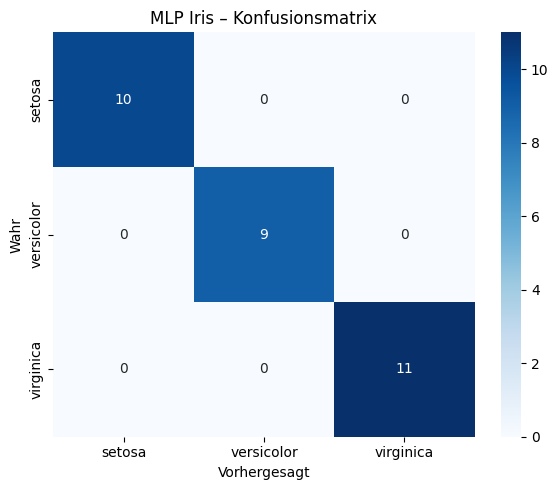

In [3]:
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 3: Mehrschichtige Netze (MLP)
# Niveau: Anfänger
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Build MLP for multiclass classification with softmax
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

tf.random.set_seed(42); np.random.seed(42)

# Iris Dataset – 3 Klassen
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# MLP mit Softmax-Ausgabe für 3 Klassen
modell = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax'),  # 3 Klassen
])
modell.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modell.fit(X_train, y_train, epochs=100, verbose=0, validation_split=0.2)

# Auswertung
y_pred = np.argmax(modell.predict(X_test, verbose=0), axis=1)
print(f"Testgenauigkeit: {modell.evaluate(X_test, y_test, verbose=0)[1]:.2%}")

# Konfusionsmatrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
ax.set_title('MLP Iris – Konfusionsmatrix')
ax.set_ylabel('Wahr'); ax.set_xlabel('Vorhergesagt')
plt.tight_layout()
plt.show()
